# MDPToolbox vs Marmote vs MDPSolver

Les 51 modèles du catalogue, avec leurs paramètres par défaut, et les 17 solveurs
de ces trois bibliothèques sont ajoutés explicitement, un par un.

Utiliser un noyau Python 3.11+ avec les dépendances installées depuis la racine :
```sh
python -m pip install -e ".[notebooks,mdptoolbox,marmote,mdpsolver,maze]"
```

Le benchmark vérifie la précision absolue par le résidu complet de Bellman.
Le timeout s'applique à chaque essai de solveur ; les modèles réutilisent leur
cache lorsqu'il existe. MDPSolver VI/SOR a un bug connu sur les récompenses
transitoires : les erreurs et imprécisions restent visibles dans les résultats.

In [1]:
# Garder les caches et les exports dans artifacts/ à la racine du dépôt.
import os
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)

In [2]:
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from mdpforge import Benchmark

DISCOUNT = 0.99
PRECISION = 1e-3
REPEATS = 3
SEED = 0
TIMEOUT = 5  # Secondes par essai ; None désactive l'isolation en processus.

np.random.seed(SEED)
random.seed(SEED)
bench = Benchmark(default_solvers=False)

In [3]:
# Solveurs : chaque ligne peut être commentée indépendamment.
bench.add_solver("mdptoolbox_vi")
bench.add_solver("mdptoolbox_vigs")
bench.add_solver("mdptoolbox_pi")
bench.add_solver("mdptoolbox_mpi")
bench.add_solver("marmote_vi")
bench.add_solver("marmote_vigs")
bench.add_solver("marmote_mpi")
bench.add_solver("marmote_mpigs")
bench.add_solver("mdpsolver_vi")
bench.add_solver("mdpsolver_vigs")
bench.add_solver("mdpsolver_visor")
bench.add_solver("mdpsolver_pi")
bench.add_solver("mdpsolver_mpi")
bench.add_solver("mdpsolver_mpigs")
bench.add_solver("mdpsolver_mpigs_init")
bench.add_solver("mdpsolver_mpisor")
bench.add_solver("mdpsolver_mpisor_init")

In [4]:
# Modèles : tous les modules publics du catalogue actuel.
bench.add_mdp("access_control")
bench.add_mdp("acrobot")
bench.add_mdp("admission")
bench.add_mdp("ambulance")
bench.add_mdp("ambulance_relocation")
bench.add_mdp("barto")
bench.add_mdp("block")
bench.add_mdp("blocks_world")
bench.add_mdp("car_rental")
bench.add_mdp("cartpole")
bench.add_mdp("chain_walk")
bench.add_mdp("cliff")
bench.add_mdp("dam")
bench.add_mdp("elevator")
bench.add_mdp("forest")
bench.add_mdp("frozen")
bench.add_mdp("gambler")
bench.add_mdp("garnet")
bench.add_mdp("hexagonal_grid_soccer")
bench.add_mdp("impatience")
bench.add_mdp("inventory")
bench.add_mdp("inventory_leadtime")
bench.add_mdp("local_perception_grid_world")
bench.add_mdp("lqr")
bench.add_mdp("m_maze")
bench.add_mdp("maintenance")
bench.add_mdp("maze_backtrack")
bench.add_mdp("maze_prims")
bench.add_mdp("maze_wilson")
bench.add_mdp("mountain")
bench.add_mdp("ninerooms")
bench.add_mdp("office_world")
bench.add_mdp("oil")
bench.add_mdp("oil_discovery")
bench.add_mdp("option_pricing")
bench.add_mdp("peg_solitaire")
bench.add_mdp("queue_network")
bench.add_mdp("random_walk")
bench.add_mdp("replacement")
bench.add_mdp("rooms")
bench.add_mdp("schoolboy")
bench.add_mdp("sutton")
bench.add_mdp("swim")
bench.add_mdp("sysadmin")
bench.add_mdp("tandem")
bench.add_mdp("tandem_choice")
bench.add_mdp("taxi")
bench.add_mdp("tictactoe")
bench.add_mdp("unichain")
bench.add_mdp("windgrid")
bench.add_mdp("wumpus_world")

In [5]:
results = bench.run(
    discount=DISCOUNT,
    precision=PRECISION,
    repeats=REPEATS,
    seed=SEED,
    timeout=TIMEOUT,
    verbose=True,
)
df = pd.DataFrame(results)
bench.export_csv(ROOT / "artifacts/results/backends_benchmark.csv")
display(pd.crosstab(df["solver"], df["status"]))

20_2_access_control / mdptoolbox_vi [1/3]: success (0.004 s)
20_2_access_control / mdptoolbox_vi [2/3]: success (0.004 s)
20_2_access_control / mdptoolbox_vi [3/3]: success (0.004 s)
20_2_access_control / mdptoolbox_vigs [1/3]: success (0.029 s)
20_2_access_control / mdptoolbox_vigs [2/3]: success (0.029 s)
20_2_access_control / mdptoolbox_vigs [3/3]: success (0.029 s)
20_2_access_control / mdptoolbox_pi [1/3]: success (0.004 s)
20_2_access_control / mdptoolbox_pi [2/3]: success (0.004 s)
20_2_access_control / mdptoolbox_pi [3/3]: success (0.004 s)
20_2_access_control / mdptoolbox_mpi [1/3]: success (0.002 s)
20_2_access_control / mdptoolbox_mpi [2/3]: success (0.003 s)
20_2_access_control / mdptoolbox_mpi [3/3]: success (0.002 s)
20_2_access_control / marmote_vi [1/3]: success (0.005 s)
20_2_access_control / marmote_vi [2/3]: success (0.005 s)
20_2_access_control / marmote_vi [3/3]: success (0.005 s)
20_2_access_control / marmote_vigs [1/3]: success (0.005 s)
20_2_access_control / mar

status,error,success,timeout
solver,,,
marmote_mpi,3,150,0
marmote_mpigs,3,150,0
marmote_vi,3,150,0
marmote_vigs,3,150,0
mdpsolver_mpi,3,150,0
mdpsolver_mpigs,3,150,0
mdpsolver_mpigs_init,3,150,0
mdpsolver_mpisor,3,150,0
mdpsolver_mpisor_init,3,150,0


In [6]:
# Temps médians en secondes ; NaN si au moins une répétition a échoué.
groups = [df["model"], df["solver"]]
valid = df["status"].eq("success").groupby(groups, sort=False).all()
median_times = df.groupby(["model", "solver"], sort=False)["runtime"].median()
display(median_times.where(valid).unstack("solver"))

# Détails des essais qui n'ont pas atteint la précision demandée.
display(
    df.loc[
        df["status"].ne("success"),
        ["model", "solver", "status", "error_bound", "error"],
    ].drop_duplicates()
)

solver,mdptoolbox_vi,mdptoolbox_vigs,mdptoolbox_pi,mdptoolbox_mpi,marmote_vi,marmote_vigs,marmote_mpi,marmote_mpigs,mdpsolver_vi,mdpsolver_vigs,mdpsolver_visor,mdpsolver_pi,mdpsolver_mpi,mdpsolver_mpigs,mdpsolver_mpigs_init,mdpsolver_mpisor,mdpsolver_mpisor_init
model,,,,,,,,,,,,,,,,,
20_2_access_control,0.003661,0.029003,0.004170,0.002487,0.005057,0.004928,0.004353,0.004526,0.004486,0.005907,NaN,0.004250,0.004181,0.004663,0.004620,0.004590,0.004704
257_3_acrobot,0.070974,0.984028,0.011153,0.109080,0.012166,0.012511,0.007744,0.007558,0.013506,0.012973,0.005882,0.008088,0.007964,0.005758,0.007122,0.005665,0.007033
108_2_admission_control,0.012909,0.161012,0.003556,0.005603,0.016308,0.015318,0.014579,0.014729,0.014030,0.019737,NaN,0.013679,0.013296,0.015009,0.014838,0.014742,0.015005
10_10_ambulance,NaN,NaN,0.003951,0.002056,0.007321,0.007190,0.006925,0.006637,0.006192,0.006242,0.006182,0.005843,0.005740,0.005895,0.006073,0.005890,0.006102
50_10_ambulance_relocation,0.026219,0.211487,0.004200,0.003095,0.198077,0.196502,0.189694,0.184298,0.169037,0.227726,0.237771,0.172828,0.166062,0.175168,0.176523,0.175296,0.173136
146_9_barto_3_0.1,0.060265,0.015045,NaN,0.007963,0.012016,0.011965,0.012714,0.012645,0.010711,0.022427,0.010670,0.011732,0.010343,0.010380,0.010384,0.010459,0.010297
100_10_block_0.85_10,0.060333,0.666117,0.007555,0.016261,0.095044,0.087676,0.078064,0.077838,0.078159,0.106557,NaN,0.072806,0.069742,0.075514,0.074328,0.075342,0.073322
96_6_blocks_world,0.074736,0.665540,0.006201,0.050891,0.009508,0.009727,0.005682,0.005707,0.009972,0.010215,NaN,0.005137,0.005334,0.004489,0.004350,0.004370,0.004362
25_9_jacks_car_rental,0.012742,0.143645,0.004662,0.003181,0.047981,0.043987,0.041683,0.042096,0.038702,0.055378,NaN,0.039684,0.038126,0.041236,0.041305,0.042937,0.042117


,model,solver,status,error_bound,error
30,20_2_access_control,mdpsolver_visor,error,NaN,RuntimeError: VI precision not reached: error ...
132,108_2_admission_control,mdpsolver_visor,error,NaN,RuntimeError: VI precision not reached: error ...
153,10_10_ambulance,mdptoolbox_vi,error,NaN,AssertionError: MDPToolbox VI requires noncons...
156,10_10_ambulance,mdptoolbox_vigs,error,NaN,ValueError: math domain error
261,146_9_barto_3_0.1,mdptoolbox_pi,timeout,NaN,Trial exceeded timeout of 5 s
336,100_10_block_0.85_10,mdpsolver_visor,error,NaN,RuntimeError: VI precision not reached: error ...
387,96_6_blocks_world,mdpsolver_visor,error,NaN,RuntimeError: VI precision not reached: error ...
438,25_9_jacks_car_rental,mdpsolver_visor,error,NaN,RuntimeError: VI precision not reached: error ...
459,625_2_cartpole_5_5_5_5,mdptoolbox_vi,error,NaN,AssertionError: MDPToolbox VI requires noncons...
642,100_10_dam,mdpsolver_visor,error,NaN,RuntimeError: VI precision not reached: error ...


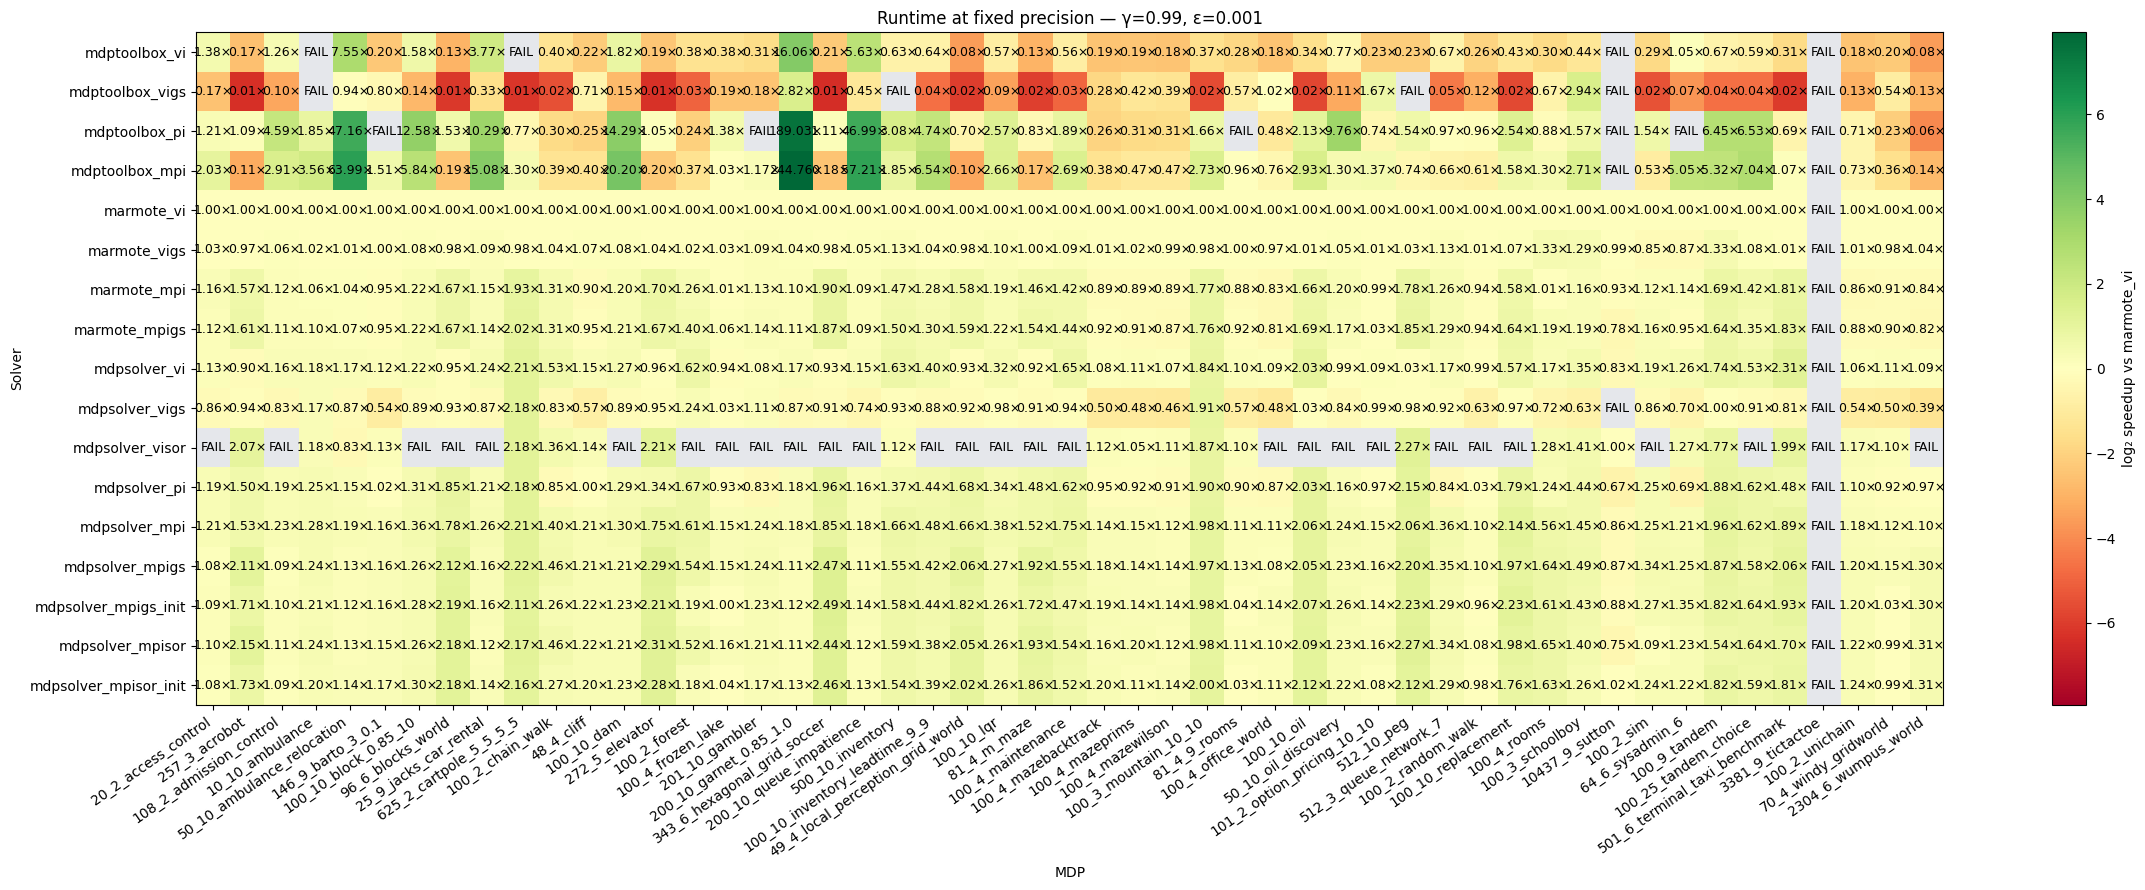

In [8]:
# Gain de vitesse par rapport à MDPToolbox VI ; FAIL = essai non validé.
fig, ax = plt.subplots(figsize=(24, 9))
bench.plot_heat(reference="marmote_vi", ax=ax, show=False)
plt.show()